# SRR26107673 Diagnostic Notebook

This notebook investigates why `SRR26107673` behaves differently from the other tumor samples in the HM450K-vs-WGBS MethylSeg figures.

The main questions are:
- How many WGBS loci are actually usable after prep filtering?
- How does that compare with HM450K support?
- Are the surprising region counts explained by sparse WGBS coverage?
- Is there evidence of a prep bug where WGBS CpGs were accidentally reduced to HM450K-like coordinates?

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "repo_paths.py").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate repo_paths.py from the current working directory.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from colors import NEUTRAL_COLORS, REGION_CATEGORY_COLORS, TOOL_HIGHLIGHT_COLORS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150

RESULTS_DIR = PROJECT_ROOT / "results" / "01_region_calling_analysis"


In [2]:
TUMOR_SAMPLES = [
    "ESO26.wgbs",
    "SRR26107673",
    "TE5.wgbs",
    "WGBS_colon-primary-tumor_1_meth",
    "WGBS_colon-primary-tumor_2_meth",
    "WGBS_colon-primary-tumor_3_meth",
]
FOCUS_SAMPLE = "SRR26107673"
REFERENCE_SAMPLE = "WGBS_colon-primary-tumor_1_meth"


def comparison_prep_dir(sample_id):
    return RESULTS_DIR / "comparison" / sample_id / "shared_prep"


def methylseg_prep_dir(sample_id):
    return RESULTS_DIR / "methylseg" / sample_id / "prep"


def methylseg_out_dir(sample_id, platform):
    return RESULTS_DIR / "methylseg" / sample_id / "out" / platform / "summary_files"


def load_wgbs_tsv(sample_id):
    path = comparison_prep_dir(sample_id) / "wgbs.tsv"
    return pd.read_csv(path, sep="\t", header=None, names=["chrom", "start", "end", "meth", "cov"])


def load_meth_ref(sample_id, filename):
    path = comparison_prep_dir(sample_id) / filename
    return pd.read_csv(path, sep="\t")


def load_regions(sample_id, platform):
    path = methylseg_out_dir(sample_id, platform) / "segments_cleaned_PMD.bed"
    return pd.read_csv(path, sep="\t", header=None, usecols=[0, 1, 2], names=["chrom", "start", "end"])


def load_removed_cpgs(sample_id, platform):
    path = methylseg_prep_dir(sample_id) / f"{platform}_removed_cpgs.tsv"
    return pd.read_csv(path, sep="\t")


def summarize_sample(sample_id):
    wgbs = load_wgbs_tsv(sample_id)
    cov = pd.to_numeric(wgbs["cov"], errors="coerce")
    meth = pd.to_numeric(wgbs["meth"], errors="coerce")
    beta = np.where(cov > 0, meth / cov, np.nan)

    wgbs_ref = load_meth_ref(sample_id, "wgbs_meth_ref.tsv")
    hm_ref = load_meth_ref(sample_id, "450k_meth_ref.tsv")
    wgbs_regions = load_regions(sample_id, "wgbs")
    hm_regions = load_regions(sample_id, "hm450k")
    wgbs_removed = load_removed_cpgs(sample_id, "wgbs")

    removed_counts = wgbs_removed.get("removed_reason", pd.Series(dtype="object")).value_counts()

    return {
        "sample": sample_id,
        "raw_wgbs_rows": len(wgbs),
        "cov_gt0": int((cov > 0).sum()),
        "cov_ge5": int((cov >= 5).sum()),
        "cov_ge10": int((cov >= 10).sum()),
        "cov_ge20": int((cov >= 20).sum()),
        "positive_cov_median": float(np.median(cov[cov > 0])) if (cov > 0).any() else np.nan,
        "wgbs_meth_ref_rows": len(wgbs_ref),
        "hm450k_meth_ref_rows": len(hm_ref),
        "wgbs_regions": len(wgbs_regions),
        "hm450k_regions": len(hm_regions),
        "wgbs_removed_cov_lt10": int(removed_counts.get("cov less than 10", 0)),
        "wgbs_removed_low_coverage_like": int(removed_counts.get("low coverage like", 0)),
        "wgbs_ref_beta_mean": float(wgbs_ref["beta"].mean()),
        "wgbs_ref_beta_median": float(wgbs_ref["beta"].median()),
        "hm450k_ref_beta_mean": float(hm_ref["beta"].mean()),
        "hm450k_ref_beta_median": float(hm_ref["beta"].median()),
    }


In [3]:
summary_df = pd.DataFrame([summarize_sample(sample) for sample in TUMOR_SAMPLES])
summary_df = summary_df.sort_values("sample").reset_index(drop=True)
summary_df


,sample,raw_wgbs_rows,cov_gt0,cov_ge5,cov_ge10,cov_ge20,positive_cov_median,wgbs_meth_ref_rows,hm450k_meth_ref_rows,wgbs_regions,hm450k_regions,wgbs_removed_cov_lt10,wgbs_removed_low_coverage_like,wgbs_ref_beta_mean,wgbs_ref_beta_median,hm450k_ref_beta_mean,hm450k_ref_beta_median
0,ESO26.wgbs,18481940,18481940,18481940,13479259,7356834,16.0,13479259,190128,1334,1026,5002681,3105063,0.670187,0.826087,0.637090,0.800000
1,SRR26107673,28217009,24386658,6344518,352907,3231,3.0,352907,425651,276,905,27864102,161667,0.694512,0.900000,0.506427,0.500000
2,TE5.wgbs,26146697,26146697,26146697,23352495,12856523,19.0,23352495,457531,1810,1518,2794202,7299301,0.652295,0.826087,0.512626,0.619048
3,WGBS_colon-primary-tumor_1_meth,26782796,26782796,21590323,15144974,5022969,11.0,15144974,476268,1571,1686,11637822,3939766,0.650347,0.769231,0.452208,0.454545
4,WGBS_colon-primary-tumor_2_meth,26785342,26785342,21596183,15149166,5020645,11.0,15149166,476303,1530,1689,11636176,3993676,0.653606,0.769231,0.453916,0.458333
5,WGBS_colon-primary-tumor_3_meth,26915702,26915702,22288960,16556147,6814731,12.0,16556147,477060,1570,1688,10359555,4197778,0.658989,0.777778,0.456871,0.466667


In [4]:
focus_compare_df = summary_df.loc[
    summary_df["sample"].isin([FOCUS_SAMPLE, REFERENCE_SAMPLE])
].copy()

focus_compare_df.T


,1,3
sample,SRR26107673,WGBS_colon-primary-tumor_1_meth
raw_wgbs_rows,28217009,26782796
cov_gt0,24386658,26782796
cov_ge5,6344518,21590323
cov_ge10,352907,15144974
cov_ge20,3231,5022969
positive_cov_median,3.0,11.0
wgbs_meth_ref_rows,352907,15144974
hm450k_meth_ref_rows,425651,476268
wgbs_regions,276,1571


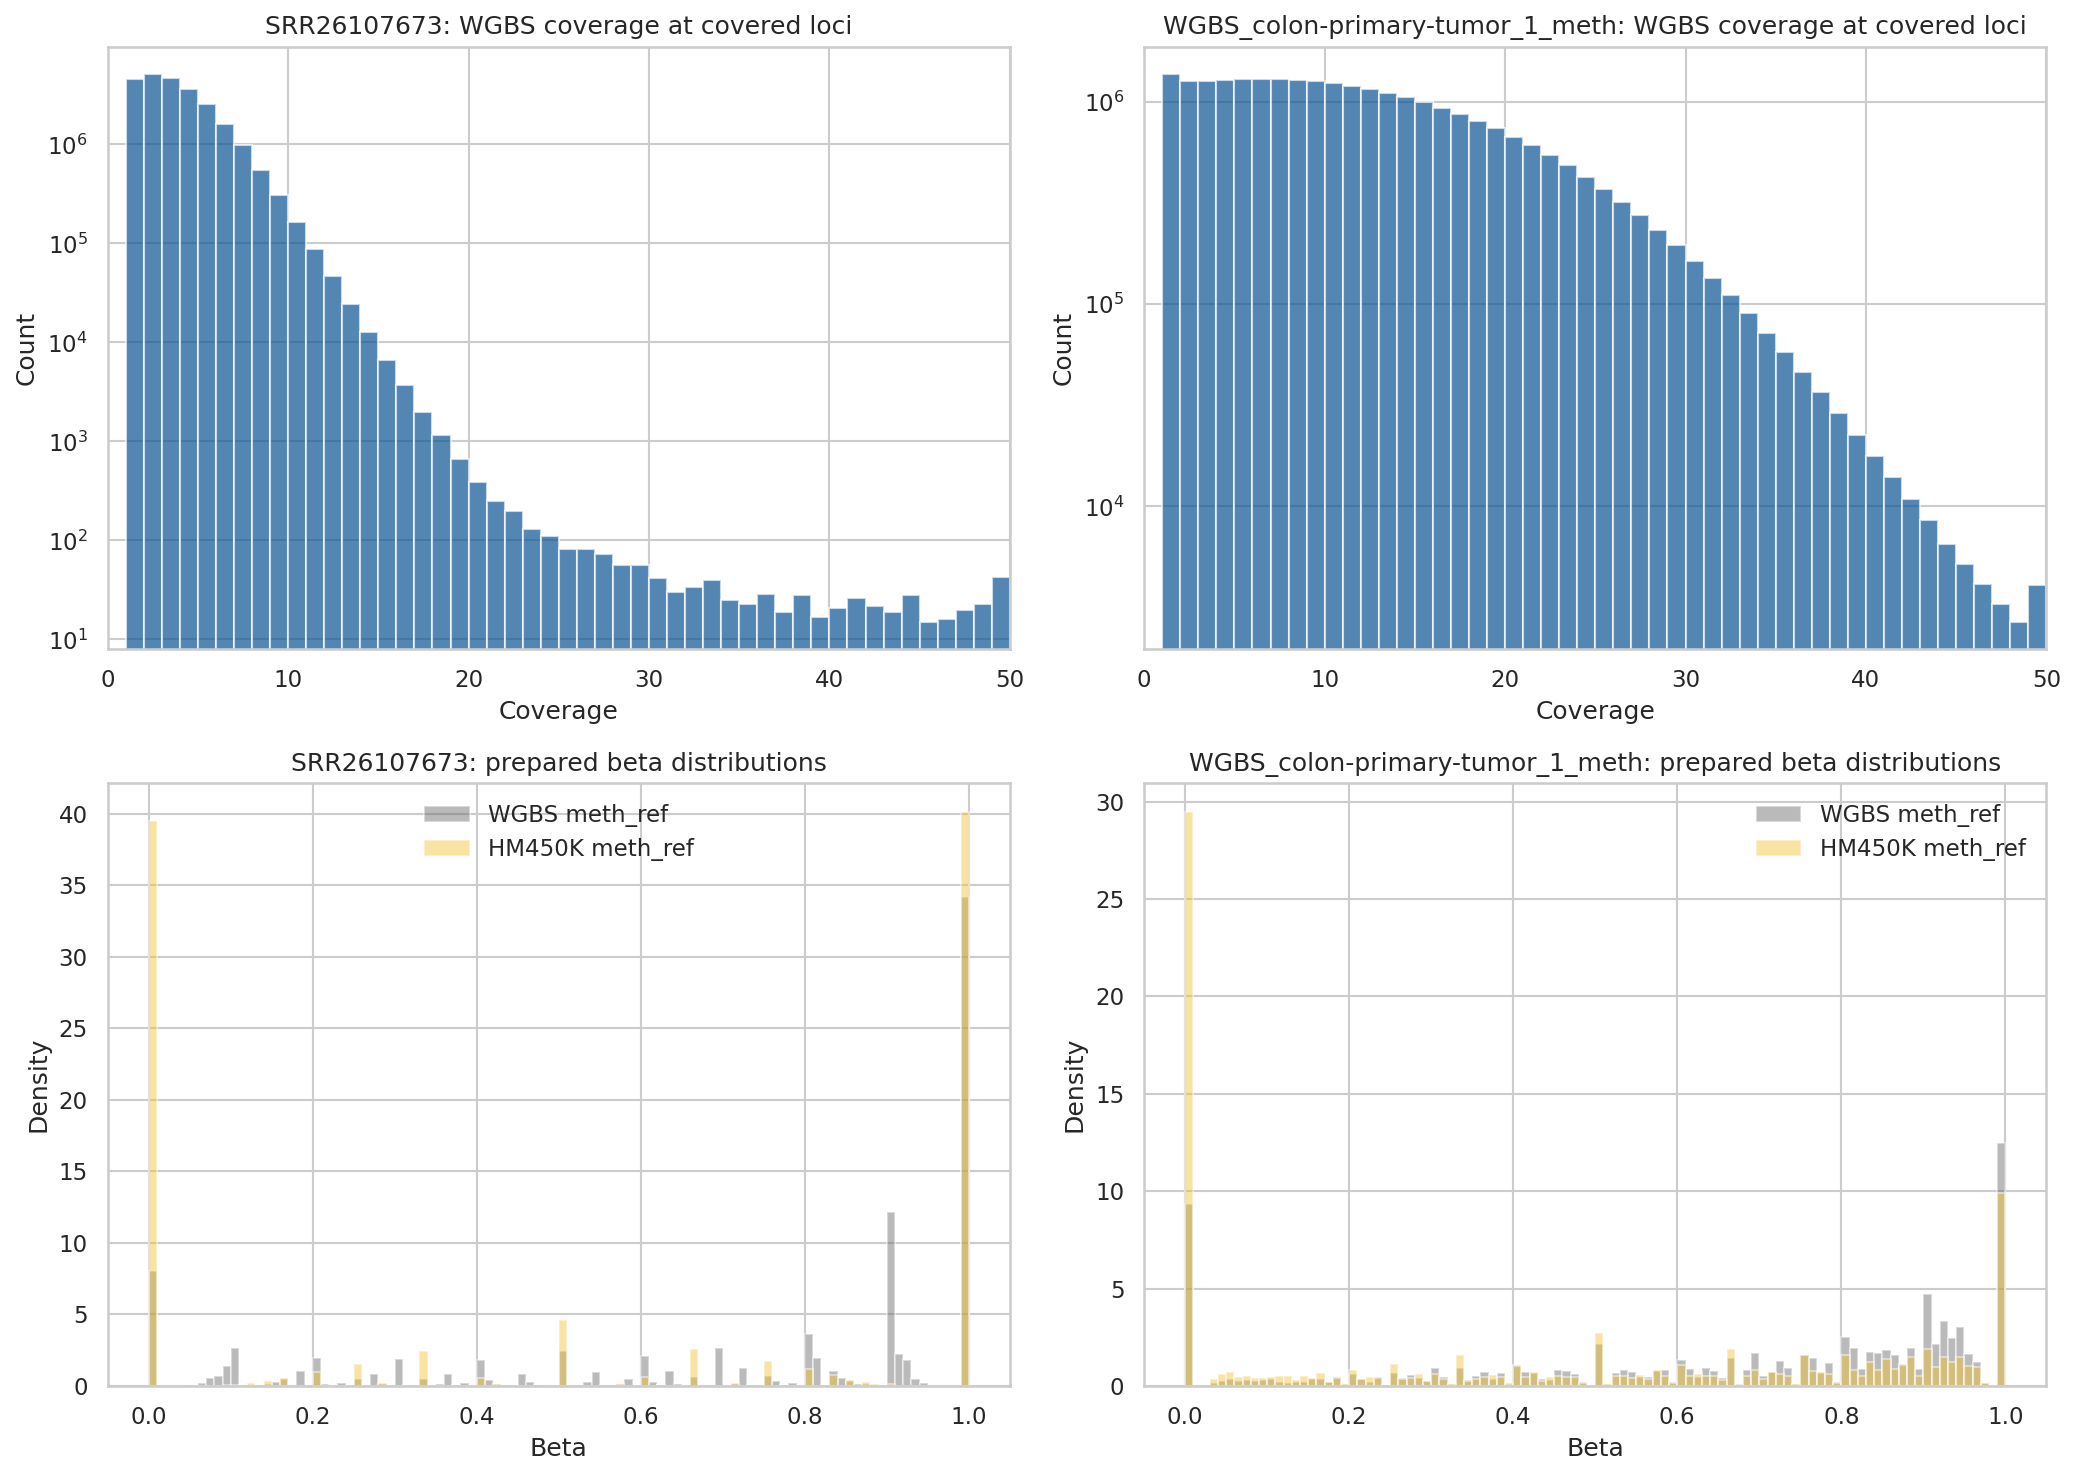

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, sample in zip(axes[0], [FOCUS_SAMPLE, REFERENCE_SAMPLE]):
    wgbs = load_wgbs_tsv(sample)
    cov = pd.to_numeric(wgbs["cov"], errors="coerce")
    cov = cov[cov > 0]
    ax.hist(cov, bins=np.arange(1, 51), color=TOOL_HIGHLIGHT_COLORS["MethylSeg WGBS"], alpha=0.7)
    ax.set_title(f"{sample}: WGBS coverage at covered loci")
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.set_xlim(0, 50)

for ax, sample in zip(axes[1], [FOCUS_SAMPLE, REFERENCE_SAMPLE]):
    wgbs_ref = load_meth_ref(sample, "wgbs_meth_ref.tsv")
    hm_ref = load_meth_ref(sample, "450k_meth_ref.tsv")
    ax.hist(wgbs_ref["beta"], bins=100, density=True, alpha=0.45, label="WGBS meth_ref", color=NEUTRAL_COLORS["text_gray"])
    ax.hist(hm_ref["beta"], bins=100, density=True, alpha=0.45, label="HM450K meth_ref", color=REGION_CATEGORY_COLORS["microarray_unique"])
    ax.set_title(f"{sample}: prepared beta distributions")
    ax.set_xlabel("Beta")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()


In [6]:
coord_overlap_rows = []
for sample in [FOCUS_SAMPLE, REFERENCE_SAMPLE]:
    wgbs_ref = load_meth_ref(sample, "wgbs_meth_ref.tsv")[["CpG_chrm", "CpG_beg", "CpG_end"]]
    hm_ref = load_meth_ref(sample, "450k_meth_ref.tsv")[["CpG_chrm", "CpG_beg", "CpG_end"]]
    shared = wgbs_ref.merge(hm_ref, on=["CpG_chrm", "CpG_beg", "CpG_end"], how="inner")
    coord_overlap_rows.append({
        "sample": sample,
        "wgbs_meth_ref_rows": len(wgbs_ref),
        "hm450k_meth_ref_rows": len(hm_ref),
        "shared_coords": len(shared),
        "pct_wgbs_meth_ref_on_hm450k": len(shared) / len(wgbs_ref),
        "pct_hm450k_meth_ref_in_wgbs": len(shared) / len(hm_ref),
    })

pd.DataFrame(coord_overlap_rows)


,sample,wgbs_meth_ref_rows,hm450k_meth_ref_rows,shared_coords,pct_wgbs_meth_ref_on_hm450k,pct_hm450k_meth_ref_in_wgbs
0,SRR26107673,352907,425651,4844,0.013726,0.011380
1,WGBS_colon-primary-tumor_1_meth,15144974,476268,363671,0.024013,0.763585


## Interpretation

What the diagnostics show so far:

- `SRR26107673` starts with a normal-sized raw `wgbs.tsv`, but almost all loci fail the WGBS `min_coverage = 10` filter before MethylSeg segmentation.
- In the saved prep outputs, `SRR26107673` retains only about `352k` WGBS CpGs in `wgbs_meth_ref.tsv`, while the colon tumor samples retain about `15M` or more.
- The removed-CpG table confirms this directly: most SRR WGBS loci are removed for `cov less than 10`.
- That much smaller WGBS CpG universe plausibly explains both of the observed notebook behaviors:
  - very few WGBS-called PMD regions
  - some regions with very high HM450K-present fractions, because the surviving WGBS CpGs inside those regions are a much smaller subset than usual
- The exact coordinate overlap between `wgbs_meth_ref.tsv` and `450k_meth_ref.tsv` is not close to 100% overall, so this does not look like a simple file-replacement bug where WGBS prep was accidentally turned into HM450K prep.

A good next check, if needed, would be to rerun the SRR WGBS side with a lower `min_coverage` and see how much the WGBS PMD count and overlap distributions recover.